取得中: 1000 / 11998 件
取得中: 2000 / 11998 件
取得中: 3000 / 11998 件
取得中: 4000 / 11998 件
取得中: 5000 / 11998 件
取得中: 6000 / 11998 件
取得中: 7000 / 11998 件
取得中: 8000 / 11998 件
取得中: 9000 / 11998 件
取得中: 10000 / 11998 件
取得中: 11000 / 11998 件
取得中: 11998 / 11998 件
取得完了: 11998件
                      canonical_smiles molecule_chembl_id relation  \
0  Cc1noc(C)c1-c1ccc2c(c1)CN(C)C(=O)N2      CHEMBL1828978        =   
1                 Cc1noc(C)c1-c1ccccc1      CHEMBL1828979        =   
2         CC(=O)c1cccc(-c2c(C)noc2C)c1      CHEMBL1828980        =   
3            CCOc1cccc(-c2c(C)noc2C)c1      CHEMBL1828981        =   
4          Cc1noc(C)c1-c1cccc(C(C)O)c1      CHEMBL1828982        =   

  standard_relation standard_units standard_value units value  
0                 =             nM         4800.0    uM   4.8  
1                 =             nM        84200.0    uM  84.2  
2                 =             nM        24600.0    uM  24.6  
3                 =             nM        23200.0    uM  23.2  
4  

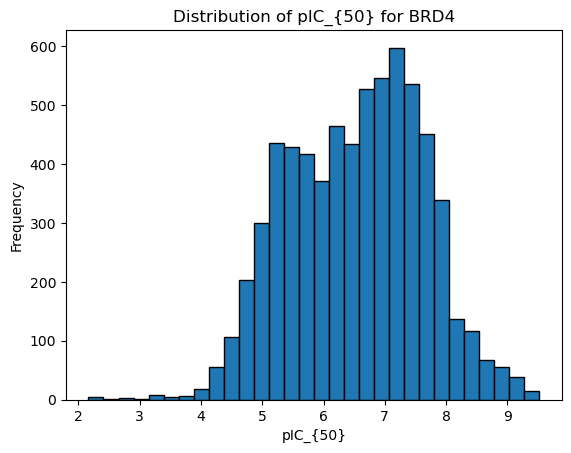

最終的なデータ件数: 6677 件
                                     standard_smiles     pIC50
0  C#CC(=O)Nc1ccc(Oc2c(C)cccc2C)c(-c2cn(C)c(=O)c3...  7.958607
1  C#CC(=O)Nc1ccc(Oc2ccc(F)cc2F)c(-c2cc(NC)c(=O)n...  7.107905
2  C#CC(=O)Nc1ccc(Oc2ccc(F)cc2F)c(-c2cn(C)c(=O)c3...  6.621602
3              C#CC1(O)C(=O)Nc2ccc(-c3c(C)noc3C)cc21  5.920819
4  C#CCNC(=O)CC1N=C(c2ccc(Cl)cc2)c2cc(OC)ccc2-c2c...  6.677781
pIC50が8以上の化合物は、516つです。
最も結合の強い化合物は、
                                        standard_smiles     pIC50
5617  Cc1nnn(C)c1-c1cnc2c3c(c(C(N)=O)nn3C)n(C(c3cccc...  9.522879


In [1]:
from chembl_webresource_client.new_client import new_client
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
import matplotlib.pyplot as plt
import urllib.request
import os 
import requests

#---活性データの取得---
#1.データ取得

target = new_client.target #変数=インスタンス.属性
res = target.filter(target_components__accession='O60885') #BRD4のUniProt ID  #変数=変数(インスタンス).メソッド
brd4_target = pd.DataFrame.from_dict(res).iloc[0] #検索結果をdfへ変換し、1行目を抽出して変数に格納。
target_id = brd4_target['target_chembl_id'] #抽出したターゲットから、chemblの識別子を取得する。
"""
activity = new_client.activity #　変数=インスタンス.属性
#BRD4に関するデータ、半数阻害濃度のデータ、単位を名のモーラーに固定　３条件でフィルタリング
query = activity.filter(target_chembl_id=target_id).filter(standard_type='IC50').filter(standard_units="nM").filter(pchembl_value__isnull=False)

query = query.only(['molecule_chembl_id', 'canonical_smiles', 'standard_value', 'standard_units', 'standard_relation']) #'standard_relation'を【追加】

data_list = list(query) #リストにすることで、pandas内部処理を介さないためダウンロードを早める
df = pd.DataFrame(data_list)
"""

#---ここからREST APIを直接叩いて、ページングしながら取得---
#BRD4に関するデータ、半数阻害濃度のデータ、単位をnMに固定 3条件でフィルタリング

url = "https://www.ebi.ac.uk/chembl/api/data/activity.json"
params = {
    "target_chembl_id": target_id,
    "standard_type": "IC50",
    "standard_units": "nM",
    "pchembl_value__isnull": "false",
    "only": "molecule_chembl_id,canonical_smiles,standard_value,standard_units,standard_relation",
    "limit": 1000,
    "offset": 0,
}

data_list = []
total_count = None

while True:
    resp = requests.get(url, params=params, timeout=60)
    resp.raise_for_status() #エラー時は例外を出す
    payload = resp.json()

    activities = payload["activities"]
    data_list.extend(activities)

    if total_count is None:
        total_count = payload["page_meta"]["total_count"]

    print(f"取得中: {len(data_list)} / {total_count} 件")

    next_page = payload["page_meta"]["next"]
    if next_page is None:
        break
    params["offset"] += params["limit"]

df = pd.DataFrame(data_list)
df.to_csv("chembl1_output.csv", index=False, encoding="utf-8")

print(f"取得完了: {len(df)}件")
print(df.head())


# 2.必要な列のみを抽出してクリーニング
df = df.dropna(subset=['canonical_smiles', 'standard_value'])
df = df[df['standard_relation'] == '='] #【追加】実測値(=)のみを残し、">"などの丸め値を除外

#【追加0715】
df['standard_value'] = df['standard_value'].astype(float) #API取得後は文字列のためfloat(数字)に変換

value_counts = df['standard_value'].value_counts()
print(f"10件以上の重複：{value_counts.head(10)}")



# 目視で確認した、アッセイのカットオフ値らしき候補のみを対象にする
cutoff_candidates = [50500.00, 25118.86, 19952.62, 15848.93, 12589.25, 10000.00, 5500.00, 2750.00, 550.00]

before = len(df)
df = df[~df['standard_value'].isin(cutoff_candidates)]
after = len(df)
print(f"除外前: {before}件 → 除外後: {after}件（{before - after}件を除外、{(before-after)/before:.1%}）")

#sub = df[df['standard_value'] == 550.0]
#print(sub['canonical_smiles'].nunique(), "個のユニークな化合物")
#print(len(sub), "件のレコード")


# 3.pI50(対数変換)の計算し、列追加。
df['pIC50'] = -np.log10(df['standard_value'] * 1e-9)

# 4.RDKitを用いたSMILESの標準化
def standardize_smlies(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        #塩の除去や電荷の中和など、標準的な形式へ変換
        return Chem.MolToSmiles(mol, isomericSmiles=True, canonical=True)
    return None

#canonical_smiles列に上記の関数を適用、欠損値は削除したものを、standard_smiles列として追加。
df['standard_smiles'] = df['canonical_smiles'].apply(standardize_smlies)
df = df.dropna(subset=['standard_smiles'])

df.to_csv("chembl2_output_standard.csv", index=False, encoding="utf-8")

#standard_smiles列の重複をまとめて、pIC50の平均値を計算
df_clean = df.groupby('standard_smiles')['pIC50'].mean().reset_index()


plt.hist(df_clean['pIC50'], bins=30, edgecolor='black')
plt.title('Distribution of pIC_{50} for BRD4')
plt.xlabel('pIC_{50}')
plt.ylabel('Frequency')
plt.show()

df_clean.to_csv("chembl3_output_clean.csv", index=False, encoding="utf-8")
print(f"最終的なデータ件数: {len(df_clean)} 件")
print(df_clean.head())


df_pIC50_over8 = df_clean[df_clean['pIC50'] >= 8]
print(f"pIC50が8以上の化合物は、{len(df_pIC50_over8)}つです。")
print("最も結合の強い化合物は、")
print(df_pIC50_over8.sort_values('pIC50', ascending=False).head(1))


In [ ]:
"""
sub = df[df['pIC50'].round(1) == 10.0]
print(sub['canonical_smiles'].nunique(), "個のユニークな化合物")
print(len(sub), "件のレコード")
"""

1 個のユニークな化合物
1 件のレコード


In [ ]:
#print(df_clean['pIC50'].describe())

count    6677.000000
mean        6.535348
std         1.096652
min         2.162412
25%         5.646853
50%         6.625252
75%         7.363847
max         9.522879
Name: pIC50, dtype: float64


２　特徴量抽出
タンパク質と、化合物をAIが理解できる数字の形式(ベクトル、行列)に変換し、次のGNNへ渡す。

In [6]:
import os
import pandas as pd
import urllib.request  
from Bio.PDB import PDBParser 
from Bio.PDB.SASA import ShrakeRupley
import torch
from torch_geometric.data import Data
from rdkit import Chem
from rdkit.Chem import Descriptors

# =====1. 前のセクションで保存したデータを読み込む======

#毎回、(時間のかかる)chemblを動作させないため
csv_file = "chembl3_output_clean.csv"

if os.path.exists(csv_file):
    print(f"--- 保存済みのデータを {csv_file} から読み込みます（ChEMBL通信をスキップ） ---")
    df_clean = pd.read_csv(csv_file)
else:
    raise FileNotFoundError(f"{csv_file} が見つかりません。最初のセクションを一度実行してファイルを作成してください。")

# =====2. RCSB PDBのダウンロードスクリプト=====
# BRD4のUniProt ID
uniprot_id = "O60885"
pdb_id = "3mxf"
pdb_filename = f"{pdb_id}.pdb"
url = f"https://files.rcsb.org/download/{pdb_filename}"

import os 
print("---RCSB PDB構造のダウンロード---")
if not os.path.exists(pdb_filename):
    print(f"---RCSB PDB DBから {pdb_filename} をダウンロード中...---")
    urllib.request.urlretrieve(url, pdb_filename)
    print(f"{pdb_id}をダウンロード完了。")
else:
    print(f"{pdb_filename} は既に存在します。")


# BD1ドメインの抽出
input_file = "3mxf.pdb"
output_file = "brd4_bd1_simple.pdb"

with open(input_file, "r") as infile, open(output_file, "w") as outfile:
    for line in infile:
        # ATOM（通常アミノ酸）で、Aチェーンで、残基番号が44〜168の行だけを書き出す
        if line.startswith("ATOM  "):
            chain_id = line[21]        # 22文字目がチェインID
            res_num = int(line[22:26]) # 23-26文字目が残基番号
            
            if chain_id == "A" and 44 <= res_num <= 168:
                outfile.write(line)

print("BD【】域の抽出が完了しました。")




#===== 3. 【重要】タンパク質のポケット周辺の特徴量数値化 =====

# PDB読み込み
parser = PDBParser(QUIET=True)
structure = parser.get_structure("BD1", "brd4_bd1_simple.pdb")

# SASAの計算。各アミノ酸の露出度を測定。
sr = ShrakeRupley()
sr.compute(structure, level="R")

#特徴量ベクトルの作成
protein_features = []
for res in structure.get_residues(): #残基を一つずつループ
    protein_features.append([res.sasa]) #sr.computeによって格納されたsasaの値を読み出し、リストに追加

protein_tensor = torch.tensor(protein_features, dtype=torch.float32) #リスト形式のデータをテンソルに変換
protein_vector = protein_tensor.flatten() #2次元行列を、1次元ベクトルに平坦化
print("---タンパク質のポケット周辺の特徴量数値化---")
print(f"アミノ酸数は{len(protein_vector)}")


#===== 4. 【重要】化合物のグラフ化構造=====

#SMILESをGNNに入力できるtorch_geometric.data.Data 形式へ変換。
def smiles_to_graph(smiles): #smilesを引数とする関数を定義。
    mol = Chem.MolFromSmiles(smiles) #RDkitを使ってsmilesを分子オブジェクト(mol)へ変換
    if mol is None: 
        return None
 

    # (1)ノード特徴量 (原子について)
    node_features = []
    for atom in mol.GetAtoms(): #分子に含まれる原子を1つずつ取り出す
        node_features.append([
            atom.GetAtomicNum(), #原子番号を特徴量(数字)として、リストに追加
            atom.GetDegree(),
            atom.GetTotalNumHs(),
            atom.GetFormalCharge(),
            int(atom.GetIsAromatic()),
            int(atom.GetHybridization()),
        ])

    x = torch.tensor(node_features, dtype=torch.float32) #原子の特徴量リストをテンソルに変換
    #[N,1]で表示。Nは分子に含まれる原子総数。列数は 今回抽出する特徴量が1種類(原子番号)だけのため。 現状水素を無視してる（確認）


    # (2)エッジインデックス (化学結合について)
    edges = [] #原子同士の化学結合の情報を格納するリスト
    edge_types = [] #【追加】結合の種類を格納するリスト
    
    for bond in mol.GetBonds(): #化学結合を一つずつ取り出してループ
        i = bond.GetBeginAtomIdx() #結合してる原子の番号を取得
        j = bond.GetEndAtomIdx()
        #[2,E×2]で表示。Eは化学結合の総数。列数の×2は、双方向を保持するため。行数の2は始点と終点のノードのインデックスを並べるため。
        bond_type = bond.GetBondTypeAsDouble() #【追加】単結合=1.0, 二重結合=2.0, 三重結合=3.0, 芳香族=1.5

        edges += [[i, j], [j, i]] #双方向のエッジを追加
        edge_types += [[bond_type], [bond_type]] #【追加】結合の種類 双方向なので2回分追加

    
    #結合がない場合の例外処理
    if not edges: 
        edge_index = torch.empty((2, 0), dtype=torch.long) #2×0の空テンソルを作成(Pytorchのルール)
        edge_type = torch.empty((0, 1), dtype=torch.float32)  #0×1の空テンソルを作成(Pytorchのルール)
    
    #結合ありの場合
    else: #結合情報を転置し、PyTorch Geometricが求める形に
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        edge_type = torch.tensor(edge_types, dtype=torch.float32)  # ★追加
    
    # (3) 分子全体の記述子 (特徴量増やすため【追加】)
    global_feats = [
        Descriptors.MolWt(mol),             # 分子量
        Descriptors.MolLogP(mol),           # 脂溶性
        Descriptors.NumHDonors(mol),        # 水素結合ドナー数
        Descriptors.NumHAcceptors(mol),     # 水素結合アクセプター数
        Descriptors.TPSA(mol),              # 極性表面積
        Descriptors.NumRotatableBonds(mol), # 回転可能結合数
        Descriptors.NumAromaticRings(mol),  # 芳香環の数
    ]
    global_x = torch.tensor(global_feats, dtype=torch.float32).unsqueeze(0)  # [1, 7]


    #PyTorch Geometricのデータオブジェクトにして返す
    data = Data(x=x, edge_index=edge_index, edge_type=edge_type)
    data.global_feat = global_x  # ★追加
    return data

sample_smiles = df_clean['standard_smiles'].iloc[0] #1行目だけを抜き出す
sample_graph = smiles_to_graph(sample_smiles) #関数を適用
print("---化合物のグラフ化---")
print(sample_graph) #表示例：Data(x=[36, 1], edge_index=[2, 78])。36個の原子(水素除く)、39本の化学結合(双方向で78)。


#=====5. 【重要】 データセット統合 (タンパクと化合物の統合)=====

from torch.utils.data import Dataset #PyTorchのデータ拡張・読み込み処理の基底クラスであるDatasetをインポート

class CPIDataset(Dataset): #化合物とタンパク質の相互作用を扱うクラス定義する
    def __init__(self, df, protein_vector): #データをクラスに読み込んで、使える準備をする。dfは化合物。
        self.smiles_list = df['standard_smiles'].values #化合物の構造をあらわすSMILES文字列を抽出し、NumPy配列としてクラス内変数(self.smiles_list)に保存。
        self.labels = df['pIC50'].values #同様に抽出し、Numpy配列として(例)[5.4, 6.2, 4.8]の形でクラス内変数に保存。
        self.protein_vector = protein_vector #引数で受け取ったタンパク質の特徴量を、クラス内変数に保存。

    def __len__(self): #データセットのサンプル数をカウント。
        return len(self.smiles_list)
        #※PyTorchの DataLoader は、ここで返された数値を見て「全部で何個のデータがあるか」を把握し、エポックごとのミニバッチ分割の計算を行う。

    def __getitem__(self, idx): #指定されたidxのデータを1件抽出し、SMILESをグラフ化構造に変換。タンパク質とセットにしてモデルが読める形にする。
            smiles = self.smiles_list[idx] #idx番目のSMILES文字列と、
            label = self.labels[idx] #それに対応するラベル(pIC50)を取り出す。

            compound_graph = smiles_to_graph(smiles) #作成した関数によって、化合物のグラフ化
            protein_feat = self.protein_vector #ターゲットのベクトルは常に同じものを返す
            compound_graph.y = torch.tensor([label], dtype=torch.float32) #pIC50をラベルとして設定
            return compound_graph, protein_feat #化合物グラフとタンパク質特徴量のタプルを返す


# ----- データセットのインスタンスを作成（統合の実行）-----
dataset = CPIDataset(df_clean, protein_vector)

print("--- データセット統合の確認 ---")
print(f"データセット全体の件数: {len(dataset)} 件")

# 1件目のデータを取り出してみる
sample_compound, sample_protein = dataset[0]

print("\n--- 1件目の抽出データ ---")
print("【化合物グラフ構造】:", sample_compound)
print("【化合物ラベル (pIC50)】:", sample_compound.y.item())
print("【タンパク質特徴量ベクトル（シェイプ）】:", sample_protein.shape)

#-----一括でPyTorchのデータファイル(.pt)を保存-----
#GNNにて、繰返しデータを読み込むため、毎回グラフ変換を実行すると遅くなる。そのため、グラフ化構造をptファイルにして保存しておく。
from tqdm import tqdm #進行状況バー

print("--- 全データの事前計算（Pre-computation）を開始 ---")
precomputed_data = []

for idx in tqdm(range(len(dataset))): #全データをループして、グラフ化とラベル付けを済ませる
    compound_graph, protein_feat = dataset[idx] #化合物グラフと、タンパク質特徴量

    if compound_graph is not None:
            # グラフオブジェクトの中に直接プロパティとして追加
            compound_graph.protein_feat = protein_feat.unsqueeze(0) # バッチ化のために次元を1つ増やす([125] -> [1, 125])
            # タプルではなく、グラフオブジェクト単体をリストに追加
            precomputed_data.append(compound_graph)

# ----- 分子全体の情報の標準化 -----
all_global_feats = torch.cat([d.global_feat for d in precomputed_data], dim=0)  # [N, 7]

global_mean = all_global_feats.mean(dim=0)
global_std = all_global_feats.std(dim=0) + 1e-6  # ゼロ除算防止

for d in precomputed_data:
    d.global_feat = (d.global_feat - global_mean) / global_std

print("global_featの標準化が完了しました")
print(f"平均: {global_mean}")
print(f"標準偏差: {global_std}")
# -----

output_filename = "brd4_cpi_dataset.pt" #データセットファイル
torch.save(precomputed_data, output_filename) 

print(f"保存完了: {len(precomputed_data)}件のデータを {output_filename} に保存しました。")


--- 保存済みのデータを chembl3_output_clean.csv から読み込みます（ChEMBL通信をスキップ） ---
---RCSB PDB構造のダウンロード---
3mxf.pdb は既に存在します。
BD【】域の抽出が完了しました。
---タンパク質のポケット周辺の特徴量数値化---
アミノ酸数は125
---化合物のグラフ化---
Data(x=[36, 6], edge_index=[2, 78], edge_type=[78, 1], global_feat=[1, 7])
--- データセット統合の確認 ---
データセット全体の件数: 6677 件

--- 1件目の抽出データ ---
【化合物グラフ構造】: Data(x=[36, 6], edge_index=[2, 78], edge_type=[78, 1], global_feat=[1, 7], y=[1])
【化合物ラベル (pIC50)】: 7.958607196807861
【タンパク質特徴量ベクトル（シェイプ）】: torch.Size([125])
--- 全データの事前計算（Pre-computation）を開始 ---


100%|██████████| 6677/6677 [00:10<00:00, 664.71it/s]


global_featの標準化が完了しました
平均: tensor([440.2616,   3.8856,   1.4704,   5.3401,  86.5087,   5.2831,   3.3527])
標準偏差: tensor([110.7279,   1.2970,   1.1199,   2.0628,  28.7980,   2.9440,   1.0195])
保存完了: 6677件のデータを brd4_cpi_dataset.pt に保存しました。


グラフニューラルネットワーク（GNN）
「化合物の形」と「タンパク質の特徴」を両方受け取って、結合しやすさ（pIC50）を数値で予測する

1.化合物のエンコード
GCN（グラフ畳み込みネットワーク）層を用いて、化合物の原子同士のつながり（構造）を考慮した特徴量を抽出します。
各原子が持つ初期特徴量（1次元）に対して、周囲の原子の情報を混ぜ合わせながら重みを掛け合わせ、128次元のベクトルへ変換・集約します。
最後に、1つの分子に含まれる全原子のベクトルを平均化（global_mean_pool）し、化合物全体を表す1つのベクトル（128次元）を作成します。

2. タンパク質のエンコード
タンパク質の特徴量（125次元の固定長ベクトル）を、全結合層（Linear層）に通します。
ここでも独自の重みを掛け合わせることで、化合物と同じ128次元のベクトルへ変換します。

3. 特徴量の統合と予測
抽出した「化合物のベクトル（128次元）」と「タンパク質のベクトル（128次元）」を横に連結（結合）し、256次元の統合ベクトルを作ります。

この統合ベクトルをさらに全結合層に通し、化合物の特徴とタンパク質の特徴の相乗効果（相性）を学習しながら、最終的にpIC50（活性値）を表す1次元の数値として出力します。(次のセル)

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.nn import GINEConv #どことの結合か(GCNConv)に加え、どんな結合の特徴量も扱える

class CPIRegressor(nn.Module):
    
    # 学習のための道具を用意する
    def __init__(self, node_feature_dim=6, protein_feature_dim=125, global_feature_dim=7,hidden_dim=128, edge_feature_dim=1):
        # self:モデル自身、各原子にもたせる次元数、タンパク質情報の次元数、分子情報の次元数、化合物情報の次元数
        super(CPIRegressor, self).__init__()

        # 1. タンパク質エンコーダ (全結合層)
        # タンパクはただのベクトル情報のため、GCNではなく全結合層。
        self.protein_lin = nn.Linear(protein_feature_dim, hidden_dim) # 125(アミノ酸数)次元→128次元

        # 2. 化合物エンコーダ (GCN層)
        # 2つ隣までのノード情報を使って、重みをかける。これを2回実行。
         # Linear変換:6→128次元に変換。 ReLU:マイナスの数字を0にする。 Linear:128→128
        nn1 = nn.Sequential(nn.Linear(node_feature_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, hidden_dim))
        self.conv1 = GINEConv(nn1, edge_dim=edge_feature_dim)# GCN1層。6次元→128次元
        
        nn2 = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, hidden_dim))
        self.conv2 = GINEConv(nn2, edge_dim=edge_feature_dim) # GCN2層。同様に128次元

        
        # 3.化合物の分子 (全結合層)
        self.global_lin = nn.Linear(global_feature_dim, hidden_dim)

        # 4. 予測ヘッド (結合後の全結合層)
        # 化合物(hidden_dim) + タンパク質(hidden_dim) = hidden_dim * 2
        self.fc1 = nn.Linear(hidden_dim * 3, hidden_dim) # 256→128。化合物とタンパク質の関係を学習しながら圧縮。
        self.fc2 = nn.Linear(hidden_dim, 1) # 最終出力はpIC50の1次元


    #学習工程の組み立て
    def forward(self, x, edge_index, edge_type, batch, protein_feat, global_feat):
        
        # x = x / 100.0 # 原子番号を0-1付近にそろえる。
        
        # x:各原子の特徴量、edge_index:どの原子同士が結合してるか、batch:どの原子がどの分子に属するか、protein_feat:タンパクの特徴量

        # --- タンパク質の処理 ---
        p = self.protein_lin(protein_feat)
        p = F.relu(p)
        
        # --- 化合物の処理 ---
        # グラフ畳み込み
        c = self.conv1(x, edge_index, edge_type) # GCN1層目
        c = F.relu(c) # 負の値を0にする。ランプ関数で非線形を生み出す。
        c = self.conv2(c, edge_index, edge_type) # GCN2層目
        c = F.relu(c) #負の値を0にする
        
        # Global Pooling: バッチ内の各化合物の原子ベクトルを平均し、1化合物あたり1つのベクトルにする
        c = global_mean_pool(c, batch) 
        
        # 分子記述子の処理
        g = self.global_lin(global_feat)
        g = F.relu(g)

        # --- 統合と予測 ---
        # 化合物ベクトル(c)とタンパク質ベクトル(p)を横に連結 (Concatenate)
        combined = torch.cat([c, p, g], dim=1)
        
        out = self.fc1(combined) # 256→128に圧縮。
        out = F.relu(out) # 負の値を0にする。
        out = self.fc2(out) # 1次元で出力
        
        return out.squeeze() # バッチサイズ分の1次元テンソルとして返す

学習ループ

In [3]:
import torch
import torch.nn as nn
from torch_geometric.loader import DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.model_selection import train_test_split  # 【追加】
import copy #【追加】

# 1. 準備（事前計算したデータの読み込み）
# ※ここでは全体の動作確認のため、まだTrain/Testの分割は行わない
dataset = torch.load("brd4_cpi_dataset.pt")

train_dataset, val_dataset = train_test_split(dataset, test_size=0.2, random_state=42)

# バッチサイズ32でデータを並列供給するDataLoaderを作成
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)      
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)         


# 2. モデル、損失関数、最適化手法の定義

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # 計算デバイスの選択。GPUが使える場合は自動でGPUに転送する。
model = CPIRegressor().to(device) # モデルの生成と、計算デバイスへの転送。 

criterion = nn.MSELoss() # 損失関数(採点基準)の定義。連続値(pIC50)の予測なので、平均二乗誤差を使用
optimizer = Adam(model.parameters(), lr=0.001) # 最適化手法の定義。学習率0.001、調整アルゴリズムとして定番であるAdamを使用。

#学習率を、途中で自動で下げる仕組み。5エポックで改善が見られなかったら、学習率を0.5にする。
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5) 

# 【追加】Early stoppingのロジック
best_val_loss = float('inf') #今までで一番よかった検証誤差を記録。最初はinf(無限)
best_model_state = None #一番調子のよかったモデルの重みを保存する箱
patience = 15          # 15エポック連続で改善しなければ止める
patience_counter = 0 # 何エポック連続で改善してないかカウント

# 3. 学習ループ
epochs = 150

print("--- 学習開始 ---")
for epoch in range(epochs):
    model.train() # モデルを学習モードに切り替え
    total_loss = 0
    
    # DataLoaderからバッチごとにデータを取り出す
    for batch in train_loader:
        # データを計算デバイスへ転送
        batch = batch.to(device)
        
        # --- 4つの基本動作 ---
        optimizer.zero_grad() # 前のバッチの勾配(修正量)をリセット
        
        # 動作1: 予測値の計算 (Forward)
        # modelのforward関数に合わせて引数を渡す
        out = model(batch.x, batch.edge_index, batch.edge_type, batch.batch, batch.protein_feat, batch.global_feat)
        
        # 動作2: 誤差の計算 (Loss)
        loss = criterion(out, batch.y)
        
        # 動作3: 逆伝播 (Backward) どのくらいずれたか
        loss.backward()
        
        # 動作4: パラメータ更新 (Step)　重みをどうなおすか
        optimizer.step()
        
        # 誤差の記録
        total_loss += loss.item() * batch.num_graphs
        
    # 1エポック終わるごとに平均誤差を表示
    epoch_loss = total_loss / len(dataset)

    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.edge_type,batch.batch, batch.protein_feat, batch.global_feat)
            loss = criterion(out, batch.y)
            total_val_loss += loss.item() * batch.num_graphs
    val_loss = total_val_loss / len(val_dataset)  

    print(f"Epoch {epoch+1:03d} | Train Loss (MSE): {epoch_loss:.4f} | Val Loss (MSE): {val_loss:.4f}") 

    scheduler.step(val_loss)

    # ★追加：Early Stoppingのロジック
    if val_loss < best_val_loss: # 「今回の誤差」が「今までの最高記録」より小さいか?
        best_val_loss = val_loss # 新記録なら、更新。ここで初めてモデルの結果と紐づく。
        best_model_state = copy.deepcopy(model.state_dict())  # 一番良かった時点の重みを保存。deeocopyで完全独立した複製を作成し、置換りリスクを低減。
        patience_counter = 0
        print(f"  → Val Lossが更新されました（ベスト: {best_val_loss:.4f}）")
    else:
        patience_counter += 1 #新記録が出なかった場合、カウント1増
        if patience_counter >= patience: # 連続で改善しなかった回数が、上限に到達したらストップ
            print(f"  → {patience}エポック連続で改善が見られないため、学習を終了します")
            break #学習を終了

# ★追加：一番良かった時点の重みをモデルに復元
model.load_state_dict(best_model_state)
print(f"\n--- 学習終了 ---")
print(f"最良Val Loss: {best_val_loss:.4f} の時点の重みを復元しました")

# ★追加：ベストモデルをファイルに保存(後でCell 9などから再利用できるように)
torch.save(model.state_dict(), "best_model.pt")
print("最良モデルを best_model.pt として保存しました")


--- 学習開始 ---
Epoch 001 | Train Loss (MSE): 1.7089 | Val Loss (MSE): 0.9245
  → Val Lossが更新されました（ベスト: 0.9245）
Epoch 002 | Train Loss (MSE): 0.7484 | Val Loss (MSE): 0.8974
  → Val Lossが更新されました（ベスト: 0.8974）
Epoch 003 | Train Loss (MSE): 0.7252 | Val Loss (MSE): 0.8507
  → Val Lossが更新されました（ベスト: 0.8507）
Epoch 004 | Train Loss (MSE): 0.6986 | Val Loss (MSE): 0.8253
  → Val Lossが更新されました（ベスト: 0.8253）
Epoch 005 | Train Loss (MSE): 0.6899 | Val Loss (MSE): 0.8631
Epoch 006 | Train Loss (MSE): 0.7016 | Val Loss (MSE): 0.8651
Epoch 007 | Train Loss (MSE): 0.6868 | Val Loss (MSE): 0.8025
  → Val Lossが更新されました（ベスト: 0.8025）
Epoch 008 | Train Loss (MSE): 0.6879 | Val Loss (MSE): 0.7923
  → Val Lossが更新されました（ベスト: 0.7923）
Epoch 009 | Train Loss (MSE): 0.6762 | Val Loss (MSE): 0.8160
Epoch 010 | Train Loss (MSE): 0.6701 | Val Loss (MSE): 0.9032
Epoch 011 | Train Loss (MSE): 0.6537 | Val Loss (MSE): 0.8267
Epoch 012 | Train Loss (MSE): 0.6406 | Val Loss (MSE): 0.8228
Epoch 013 | Train Loss (MSE): 0.6339 | 

Pearson相関係数: 0.836
R^2: 0.699


c:\Users\todor\miniforge3\envs\bio_clean\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20104 (\N{CJK UNIFIED IDEOGRAPH-4E88}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\todor\miniforge3\envs\bio_clean\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 28204 (\N{CJK UNIFIED IDEOGRAPH-6E2C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\todor\miniforge3\envs\bio_clean\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23455 (\N{CJK UNIFIED IDEOGRAPH-5B9F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\todor\miniforge3\envs\bio_clean\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\todor\miniforge3\envs\bio_clean\lib\site-packages\IPython\core\pylabtools.py:170: UserWarni

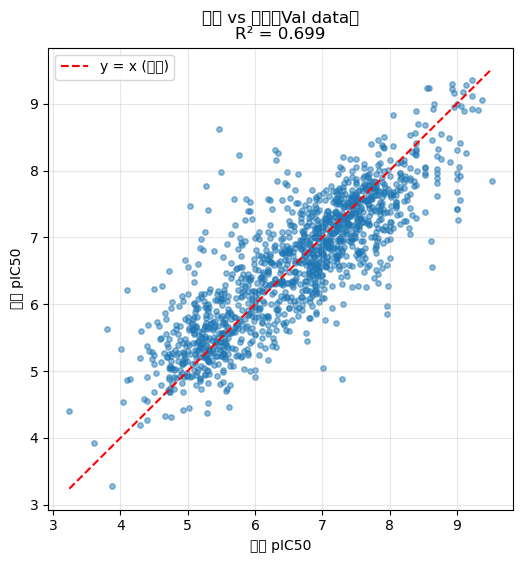

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

# 検証データに対する予測値と実測値を集める
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index,  batch.edge_type,batch.batch, batch.protein_feat,  batch.global_feat)
        all_preds.append(out.cpu())
        all_labels.append(batch.y.cpu())

all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

# 相関係数とR²
r, _ = pearsonr(all_preds, all_labels)
r2 = r ** 2
print(f"Pearson相関係数: {r:.3f}")
print(f"R^2: {r2:.3f}")

# 散布図
plt.figure(figsize=(6, 6))
plt.scatter(all_labels, all_preds, alpha=0.5, s=15)

# y=xの理想直線
min_val = min(all_labels.min(), all_preds.min())
max_val = max(all_labels.max(), all_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y = x (理想)')

plt.xlabel('実測 pIC50')
plt.ylabel('予測 pIC50')
plt.title(f'予測 vs 実測（Val data）\nR² = {r2:.3f}')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#

In [5]:
print((df_clean['pIC50'].round(1) == 4.3).sum())
print(df_clean[df_clean['pIC50'].round(1) == 4.3].head(10))

628
                                        standard_smiles     pIC50
17    C/C=C(/Oc1ccccc1)c1nc2c3c(ccc2n1[C@H]1CC[C@H](...  4.296709
18    C/C=C(\Oc1ccccc1)c1nc2c3c(ccc2n1[C@@H]1CCC[C@@...  4.296709
148          CC(=O)N(C)c1ccc(NC(=O)COc2ccc(Br)cc2Cl)cc1  4.293112
442     CC(=O)N1CCc2c(cc(-c3cccc(Cl)c3)c(=O)n2CC2CC2)C1  4.283997
731   CC(C)N1CCc2c(nnn2CC(=O)Nc2ccc(Br)c(S(=O)(=O)N3...  4.300000
1018  CCC(CC)n1c(C[C@@H](C(=O)O)c2ccccc2)nc2c3c(ccc2...  4.296709
1019  CCC(CC)n1c(C[C@H](C(=O)O)c2ccccc2)nc2c3c(ccc21...  4.296709
1028  CCC(O)(c1ccccc1)c1nc2c3c(ccc2n1[C@@H]1CCC[C@@H...  4.296709
1177  CCN(CC)S(=O)(=O)c1ccc(C2CC(=O)N(C)C2)c(-c2ccc(...  4.287350
1233        CCN1C(=O)c2cccc3c(S(=O)(=O)N4CCCCC4)ccc1c23  4.325323


In [7]:
# ===== ベースラインモデル：Random Forest + Morganフィンガープリント =====
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# ----- 1. SMILESをMorganフィンガープリントに変換する関数 -----
def smiles_to_fingerprint(smiles, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    return np.array(fp)

# ----- 2. df_cleanの全化合物をフィンガープリント化 -----
print("--- Morganフィンガープリントへの変換を開始 ---")
X = []
y = []
valid_idx = []

for idx, row in df_clean.iterrows():
    fp = smiles_to_fingerprint(row['standard_smiles'])
    if fp is not None:
        X.append(fp)
        y.append(row['pIC50'])
        valid_idx.append(idx)

X = np.array(X)
y = np.array(y)
print(f"フィンガープリント化完了: {X.shape[0]}件, 次元数: {X.shape[1]}")

# ----- 3. GNNと同じ条件でTrain/Val分割 -----
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# ----- 4. Random Forestの学習 -----
rf_model = RandomForestRegressor(n_estimators=500, max_depth=None, n_jobs=-1, random_state=42)
rf_model.fit(X_train, y_train)

# ----- 5. 評価 -----
y_pred = rf_model.predict(X_val)
rf_mse = mean_squared_error(y_val, y_pred)
rf_r2 = r2_score(y_val, y_pred)

print(f"\n--- Random Forest (ベースライン) ---")
print(f"Val Loss (MSE): {rf_mse:.4f}")
print(f"R^2: {rf_r2:.4f}")

# ----- 6. GNNとの比較表 -----
print(f"\n--- モデル比較 ---")
print(f"{'モデル':<25}{'Val Loss (MSE)':<20}{'R^2':<10}")
print(f"{'Random Forest (ベースライン)':<25}{rf_mse:<20.4f}{rf_r2:<10.4f}")
print(f"{'GNN (GINEConv+特徴量拡張)':<25}{'0.3748':<20}{'0.718*':<10}")
print("* GNNのR^2は前回Cell 9で算出した値")

--- Morganフィンガープリントへの変換を開始 ---


[17:22:11] DEPRECATION WARNING: please use MorganGenerator
[17:22:11] DEPRECATION WARNING: please use MorganGenerator
[17:22:11] DEPRECATION WARNING: please use MorganGenerator
[17:22:11] DEPRECATION WARNING: please use MorganGenerator
[17:22:11] DEPRECATION WARNING: please use MorganGenerator
[17:22:11] DEPRECATION WARNING: please use MorganGenerator
[17:22:11] DEPRECATION WARNING: please use MorganGenerator
[17:22:11] DEPRECATION WARNING: please use MorganGenerator
[17:22:11] DEPRECATION WARNING: please use MorganGenerator
[17:22:11] DEPRECATION WARNING: please use MorganGenerator
[17:22:11] DEPRECATION WARNING: please use MorganGenerator
[17:22:11] DEPRECATION WARNING: please use MorganGenerator
[17:22:11] DEPRECATION WARNING: please use MorganGenerator
[17:22:11] DEPRECATION WARNING: please use MorganGenerator
[17:22:11] DEPRECATION WARNING: please use MorganGenerator
[17:22:11] DEPRECATION WARNING: please use MorganGenerator
[17:22:11] DEPRECATION WARNING: please use MorganGenerat

フィンガープリント化完了: 6677件, 次元数: 2048

--- Random Forest (ベースライン) ---
Val Loss (MSE): 0.2891
R^2: 0.7663

--- モデル比較 ---
モデル                      Val Loss (MSE)      R^2       
Random Forest (ベースライン)   0.2891              0.7663    
GNN (GINEConv+特徴量拡張)     0.3748              0.718*    
* GNNのR^2は前回Cell 9で算出した値
